### This notebook performs the same steps performed in `classification_02 and classification_03` in the case of visit 2 predicting visit 4. 

*Note: Prediction of visit 4 from visit 1 data is performed in `classification_01` and saved in CSV. That needs to be run before this notebook can be run.* 

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
# import os
# from Carl_Response_Functions.load_responses import *
import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score


from nilearn import plotting
from nilearn import image
from nilearn import masking
from nilearn.image import concat_imgs
from sklearn.preprocessing import LabelEncoder
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.input_data import NiftiLabelsMasker
from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.decoding import FREMClassifier

from nilearn.decoding import Decoder
from sklearn.model_selection import LeaveOneGroupOut
from nilearn.plotting import plot_stat_map, show
from nilearn.plotting import view_img
from nilearn.maskers import NiftiMasker

from nilearn.decoding import SearchLight
from sklearn.preprocessing import StandardScaler


from nilearn.glm import threshold_stats_img

import numpy as np
import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import os
import subprocess
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from nilearn import plotting
import nibabel as nib
import seaborn as sns
import numpy as np

#Import classification models (SVM - Gradientboosting)
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier


from parcellation_to_classification_utils import *
from classification_functions import *
from fdr_correction_functions import *

#Change based on machine being used, for more information please refer to README "Running classification"
user = "gaia"

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


In [2]:
#Retrieve paths used for analysis, path is based on user 
base_path, tian_atlas_path, tian_label_path, z_map_path, second_level_glm_path, run_mapping = obtain_base_paths(user)

# Load the Schaefer atlas (assuming get_schaefer_parcellation is defined)
schaefer_img, schaefer_labels = get_schaefer_parcellation(n_rois=200)

# Load the Tian atlas (assuming get_tian_parcellation is defined)
tian_img, tian_labels = get_tian_parcellation(tian_atlas_path, tian_label_path)

# Combine the atlases (assuming combine_parcellations is defined)
combined_img, combined_labels = combine_parcellations(schaefer_img, tian_img, schaefer_labels, tian_labels)

## GBM visit 2 predicts visit 4

Open performance of GBM and the reshuffled csv

In [3]:
gbm_visit_2_real = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_reproduced_visit_2.json")
gbm_visit_2_null = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Null_data/GradientBoostingClassifier_reproduced_visit_2_null.json")

Save CSVs of performance

In [4]:
nr_top_parcels = 12
gbm_visit_2_real_setup_info, gbm_visit_2_real_classifier_df, gbm_visit_2_real_top_parcels = display_top_ROIs_from_classifier(gbm_visit_2_real, 
                                                                                                                            nr_top_parcels,
                                                                                                                            setup = True)

gbm_visit_2_null_setup_info, gbm_visit_2_null_classifier_df, gbm_visit_2_null_top_parcels = display_top_ROIs_from_classifier(gbm_visit_2_null, 
                                                                                                                            nr_top_parcels,
                                                                                                                            setup = True)    

### Permutation test

In [5]:
#Classifier name
classifier_name = "GradientBoostingClassifier"

#Obtain results of permutation test (empirical p-values)
gbm_permutation_visit_2 = permutation_test( gbm_visit_2_null_classifier_df, gbm_visit_2_real_classifier_df)

#Pick number of parcels to study
nr_top_parcels = 20 

# Filter by those results that are below 0.05
significant_results = gbm_permutation_visit_2 [gbm_permutation_visit_2 ["p_value"] < 0.05]

# Then sort and take top N (up to nr_top_parcels)
gbm_top_permutation = significant_results.sort_values(by="p_value", ascending=True).head(nr_top_parcels)

# Generate path to store the significant parcels df 
save_path = generate_output_significant_parcels(base_path, classifier_name, "fMRI")

#By default, the values are saved in Intermediate_Files under classifier_name dir
gbm_top_permutation.to_csv(os.path.join(save_path, "visit_2_gbm_significant_parcels_df"), index=False)

### Perform FDR correction

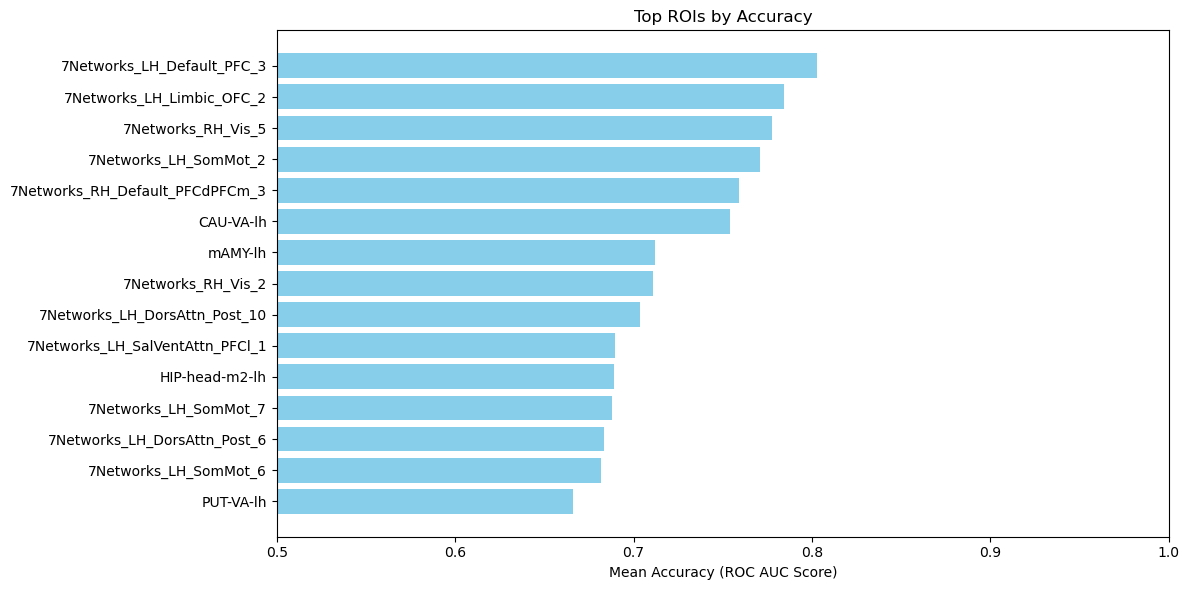

In [6]:

gbm_visit2_significant = pd.read_csv("Results/Intermediate_Files/fMRI_Classifiers_Significant_Output/GradientBoostingClassifier/visit_2_gbm_significant_parcels_df")
gbm_visit2_bh_significant = benjamini_hochberg(gbm_visit2_significant, model="GBM", prediction ="visit_2")

### Visualise regions that survive FDR correction

7Networks_LH_Default_PFC_3
7Networks_LH_Limbic_OFC_2
7Networks_RH_Vis_5
7Networks_LH_SomMot_2
7Networks_RH_Default_PFCdPFCm_3
CAU-VA-lh
mAMY-lh
7Networks_RH_Vis_2
7Networks_LH_DorsAttn_Post_10
7Networks_LH_SalVentAttn_PFCl_1
HIP-head-m2-lh
7Networks_LH_SomMot_7
7Networks_LH_DorsAttn_Post_6
7Networks_LH_SomMot_6
PUT-VA-lh


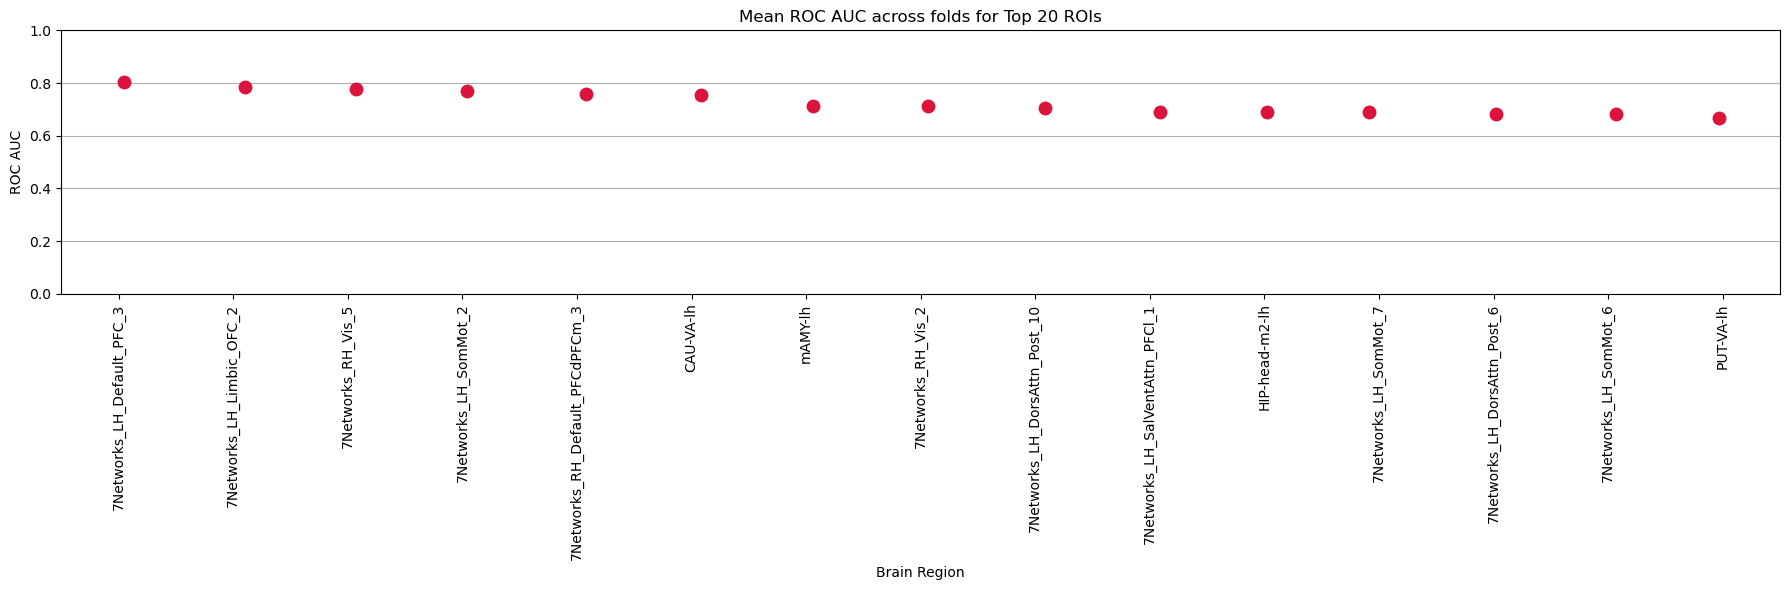

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


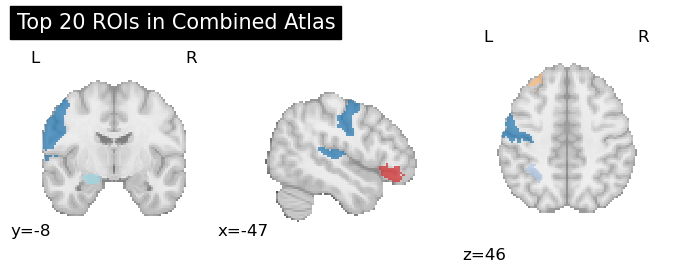

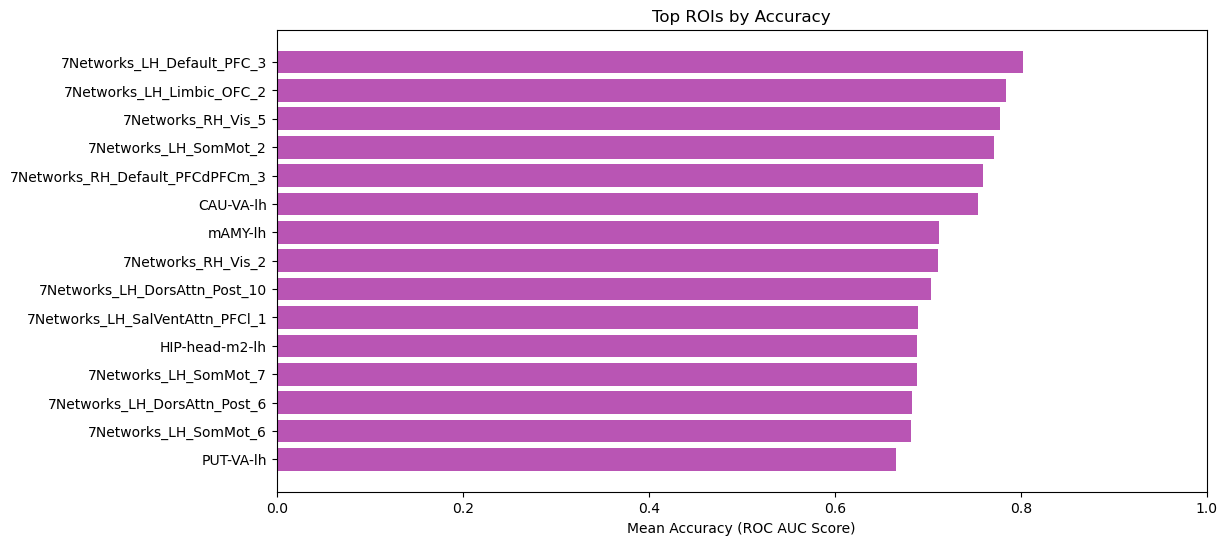

In [7]:
#number of top parcels to consider
nr_top_parcels = 20

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(gbm_visit2_bh_significant, base_path, combined_labels, combined_img, top_n=nr_top_parcels,
                                       save_nifti = False)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
# confusion_matrix_per_fold(gbm_top_parcels)

barplot_top_ROIs(gbm_visit2_significant, nr_top_parcels, model_used = "GBM")

### Naming

In [8]:
visit2_gbm_bh_significant_copy = gbm_visit2_bh_significant.copy()
visit2_gbm_bh_significant = parcel_to_network_name(visit2_gbm_bh_significant_copy)

### Extract coordinates to get name and 3d visualisation from MRIcroGL and FSLeyes

In [ ]:
extract_coordinates_from_nifti(base_path, model="GBM", type_prediction = "visit2")

In [11]:
gbm_visit2_mapping = {
            "Left Default Mode Network_3" : "lOFC, L", #orbitofrontal cortex
            "Left Limbic System_2" : "OFC, L", 
            "Right Visual Cortex_5":"LOC, R", #lateral occipital cortex
            "Left Somatomotor Cortex_2" : "A1, L", #primary auditory cortex
            "Right Default Mode Network_3":"ACC, R",
            "Left Ventral Anterior Caudate":"CN, L", #ventral anterior caudate (CN is caudate nucleus)
            "Left Middle Amygdala": "MeA, L", #Left Middle Amygdala
            "Right Visual Cortex_2":"PHC, R", #Parahippocampal Gyrus and Lingual Cortex
            "Left Parietal Cortex_10" : "SPC, L", #postcentral gyrus
            "Left Salience / Ventral Attention Network_1" : "dlPFC, L", #left dorsolateral prefrontal cortex
            "Left Hippocampal Head, Medial Cluster 2" : "Hipp, L", #Left Hippocampus (cornus ammonis)
            "Left Somatomotor Cortex_7" : "PMC/M1, L", #premotor cortex


            "Left Parietal Cortex_6" : "SPL, L",
            "Left Somatomotor Cortex_6" : "PoCG, L",
            "Left Ventral Anterior Putamen":"VAP, L", #ventral anterior putamen
            
                }

1       0 - lOFC, L
3        0 - OFC, L
2        0 - LOC, R
0         0 - A1, L
5        0 - ACC, R
4         0 - CN, L
6        0 - MeA, L
7        0 - PHC, R
8        0 - SPC, L
11     0 - dlPFC, L
9       0 - Hipp, L
10    0 - PMC/M1, L
12       0 - SPL, L
14      0 - PoCG, L
13       0 - VAP, L
Name: plot_label, dtype: object


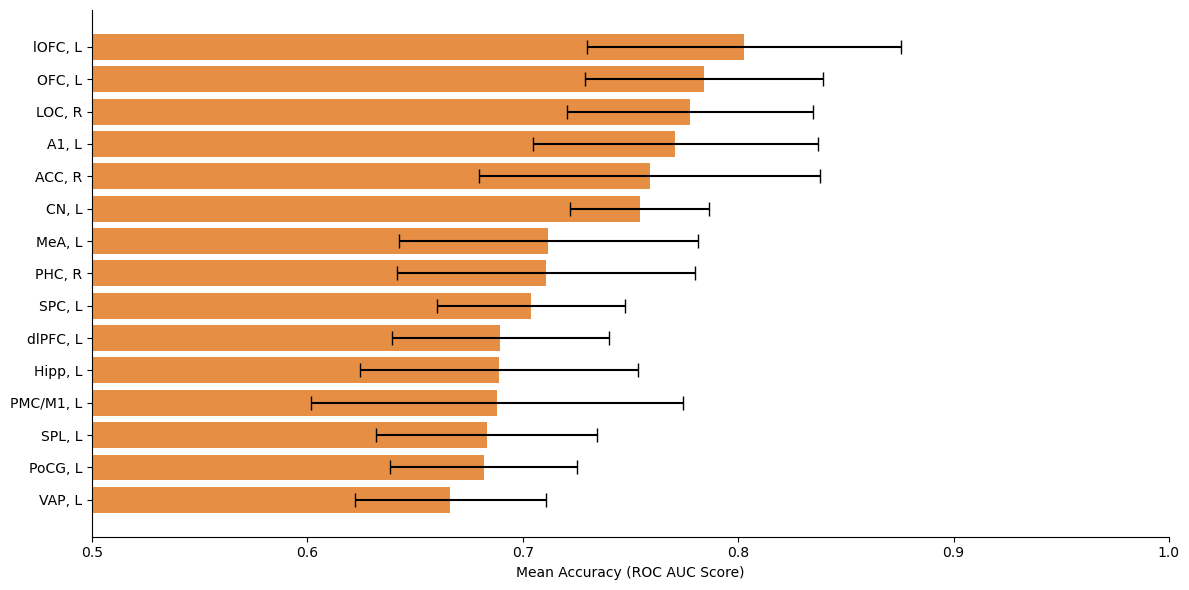

In [12]:
plot_human_labels(visit2_gbm_bh_significant, base_path, gbm_visit2_mapping,
                   model="visit2_GBM", prediction="visit_2", FDR_method="BH", error_bar = True)

Left Default Mode Network_3
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_GBM/Left Default Mode Network_3_mask.nii.gz
Left Limbic System_2
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_GBM/Left Limbic System_2_mask.nii.gz
Right Visual Cortex_5
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_GBM/Right Visual Cortex_5_mask.nii.gz
Left Somatomotor Cortex_2
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_GBM/Left Somatomotor Cortex_2_mask.nii.gz
Right Default Mode Network_3
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_GBM/Right Default Mode Network_3_mask.nii.gz
Left Ventral Anterior Caudate
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_GBM/Left Ventral Anterior Caudate_mask.nii.gz
Left Middle Amygdala
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_GBM/Left Middle Amygdala_mask.nii.gz
Right Visual Cortex_2
Saved: /scratch/gp565/

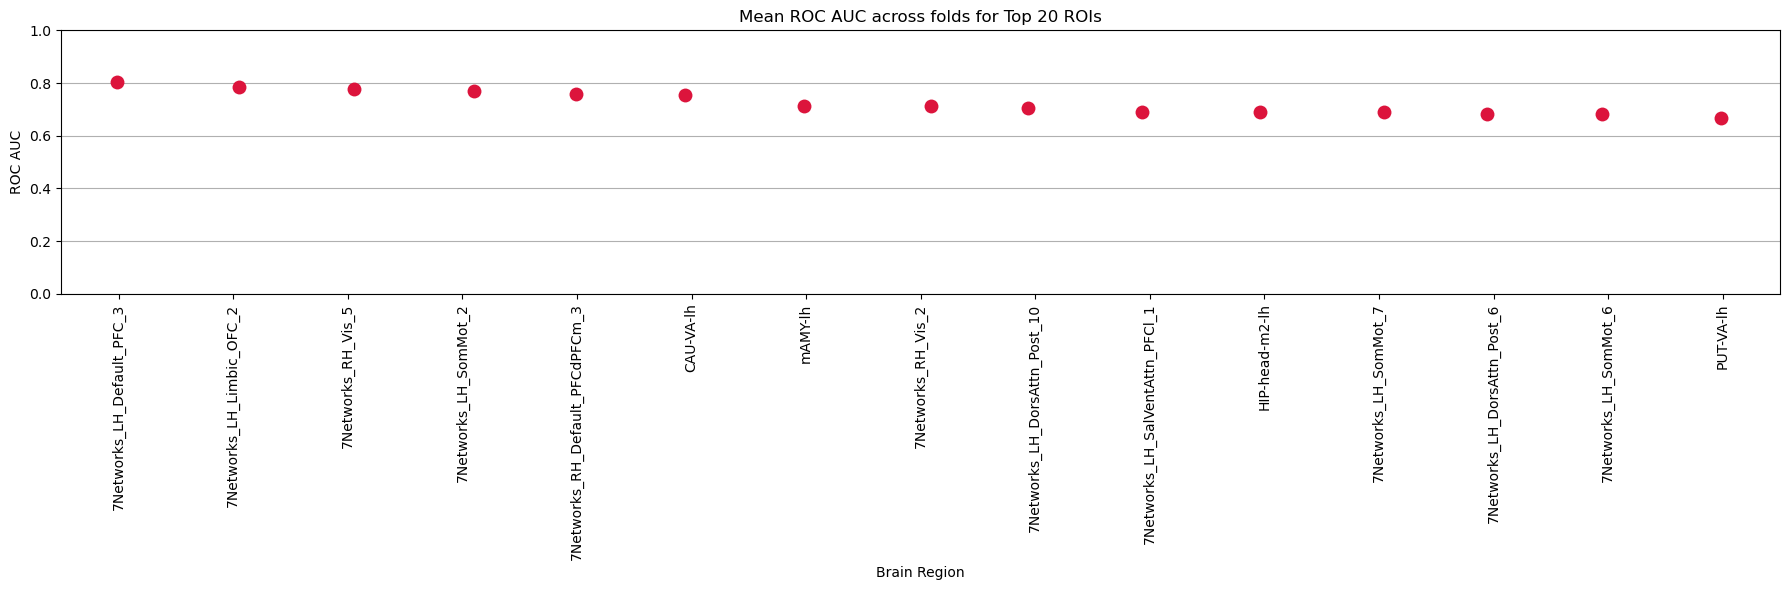

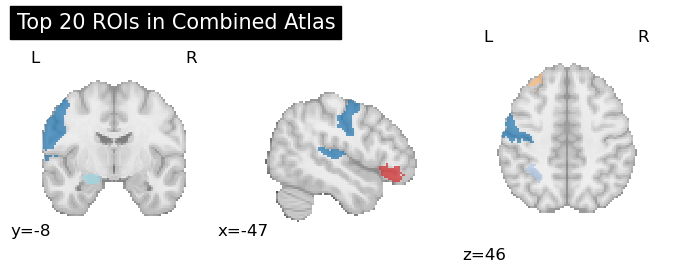

In [13]:
gbm_bh_visit2_pred = visualize_top_rois_from_performance_df(visit2_gbm_bh_significant, base_path, combined_labels, combined_img, top_n=20,
                                           model = "visit2_GBM",
                                           save_nifti = True,
                                           plot_glass_brain = False,
                                           do_surface_plot = False)

In [14]:
display(visit2_gbm_bh_significant)


,brain_region,performance_stats,confusion_matrices,mean_performance,n_extreme,p_value,mean_over_folds,rank,BH_threshold,region_name,roi_anatomical_name,plot_label
1,7Networks_LH_Default_PFC_3,"{'mean': 0.802619047619047, 'std': 0.145970829...","[[[5, 0], [1, 5]], [[4, 0], [2, 5]], [[2, 2], ...",0.802619,2,0.002,0.802619,2,0.006667,Left Default Mode Network_3,"lOFC, L","0 - lOFC, L"
3,7Networks_LH_Limbic_OFC_2,"{'mean': 0.784285714285714, 'std': 0.110347318...","[[[4, 1], [1, 5]], [[4, 0], [2, 5]], [[2, 2], ...",0.784286,3,0.003,0.784286,4,0.013333,Left Limbic System_2,"OFC, L","0 - OFC, L"
2,7Networks_RH_Vis_5,"{'mean': 0.7775000000000001, 'std': 0.11412712...","[[[3, 2], [0, 6]], [[3, 1], [2, 5]], [[3, 1], ...",0.777500,2,0.002,0.777500,3,0.010000,Right Visual Cortex_5,"LOC, R","0 - LOC, R"
0,7Networks_LH_SomMot_2,"{'mean': 0.770833333333333, 'std': 0.132244705...","[[[4, 1], [2, 4]], [[4, 0], [2, 5]], [[4, 0], ...",0.770833,0,0.000,0.770833,1,0.003333,Left Somatomotor Cortex_2,"A1, L","0 - A1, L"
5,7Networks_RH_Default_PFCdPFCm_3,"{'mean': 0.7589285714285711, 'std': 0.15802422...","[[[5, 0], [1, 5]], [[4, 0], [1, 6]], [[4, 0], ...",0.758929,5,0.005,0.758929,6,0.020000,Right Default Mode Network_3,"ACC, R","0 - ACC, R"
4,CAU-VA-lh,"{'mean': 0.754285714285714, 'std': 0.064305993...","[[[4, 1], [1, 5]], [[2, 2], [0, 7]], [[3, 1], ...",0.754286,3,0.003,0.754286,5,0.016667,Left Ventral Anterior Caudate,"CN, L","0 - CN, L"
6,mAMY-lh,"{'mean': 0.711785714285714, 'std': 0.138891587...","[[[2, 3], [0, 6]], [[2, 2], [1, 6]], [[4, 0], ...",0.711786,18,0.018,0.711786,7,0.023333,Left Middle Amygdala,"MeA, L","0 - MeA, L"
7,7Networks_RH_Vis_2,"{'mean': 0.71095238095238, 'std': 0.1384609279...","[[[3, 2], [2, 4]], [[4, 0], [4, 3]], [[4, 0], ...",0.710952,21,0.021,0.710952,8,0.026667,Right Visual Cortex_2,"PHC, R","0 - PHC, R"
8,7Networks_LH_DorsAttn_Post_10,"{'mean': 0.7038095238095231, 'std': 0.08726896...","[[[5, 0], [2, 4]], [[2, 2], [1, 6]], [[4, 0], ...",0.703810,30,0.030,0.703810,9,0.030000,Left Parietal Cortex_10,"SPC, L","0 - SPC, L"
11,7Networks_LH_SalVentAttn_PFCl_1,"{'mean': 0.689642857142857, 'std': 0.100965857...","[[[3, 2], [1, 5]], [[3, 1], [2, 5]], [[3, 1], ...",0.689643,32,0.032,0.689643,12,0.040000,Left Salience / Ventral Attention Network_1,"dlPFC, L","0 - dlPFC, L"


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


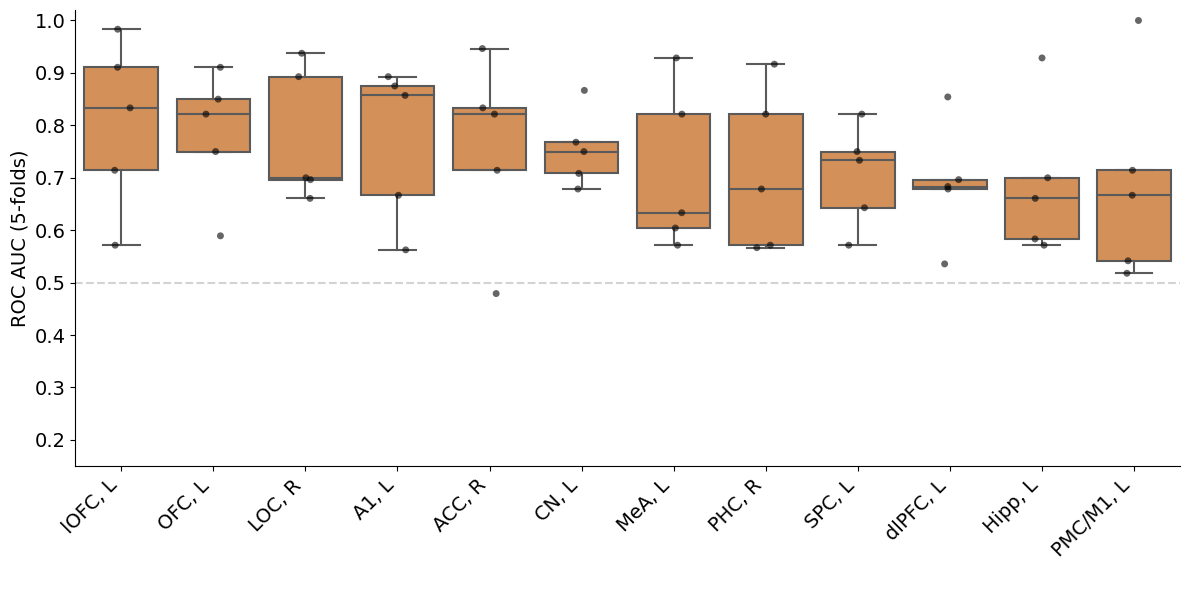

In [15]:
boxplot_ROC_AUC_performance(visit2_gbm_bh_significant, "visit2_GBM")

### Confusion matrices and 3D Visualisations

In [17]:
get_surface_plot_path(visit2_gbm_bh_significant, base_path, model = "GBM", type_prediction="visit2")

,brain_region,performance_stats,confusion_matrices,mean_performance,n_extreme,p_value,mean_over_folds,rank,BH_threshold,region_name,roi_anatomical_name,plot_label,surface_plot_path
1,7Networks_LH_Default_PFC_3,"{'mean': 0.802619047619047, 'std': 0.145970829...","[[[5, 0], [1, 5]], [[4, 0], [2, 5]], [[2, 2], ...",0.802619,2,0.002,0.802619,2,0.006667,Left Default Mode Network_3,"lOFC, L","0 - lOFC, L",Left Default Mode Network_3_surface_plot.png
3,7Networks_LH_Limbic_OFC_2,"{'mean': 0.784285714285714, 'std': 0.110347318...","[[[4, 1], [1, 5]], [[4, 0], [2, 5]], [[2, 2], ...",0.784286,3,0.003,0.784286,4,0.013333,Left Limbic System_2,"OFC, L","0 - OFC, L",Left Limbic System_2_surface_plot.png
2,7Networks_RH_Vis_5,"{'mean': 0.7775000000000001, 'std': 0.11412712...","[[[3, 2], [0, 6]], [[3, 1], [2, 5]], [[3, 1], ...",0.777500,2,0.002,0.777500,3,0.010000,Right Visual Cortex_5,"LOC, R","0 - LOC, R",Right Visual Cortex_5_surface_plot.png
0,7Networks_LH_SomMot_2,"{'mean': 0.770833333333333, 'std': 0.132244705...","[[[4, 1], [2, 4]], [[4, 0], [2, 5]], [[4, 0], ...",0.770833,0,0.000,0.770833,1,0.003333,Left Somatomotor Cortex_2,"A1, L","0 - A1, L",Left Somatomotor Cortex_2_surface_plot.png
5,7Networks_RH_Default_PFCdPFCm_3,"{'mean': 0.7589285714285711, 'std': 0.15802422...","[[[5, 0], [1, 5]], [[4, 0], [1, 6]], [[4, 0], ...",0.758929,5,0.005,0.758929,6,0.020000,Right Default Mode Network_3,"ACC, R","0 - ACC, R",Right Default Mode Network_3_surface_plot.png
4,CAU-VA-lh,"{'mean': 0.754285714285714, 'std': 0.064305993...","[[[4, 1], [1, 5]], [[2, 2], [0, 7]], [[3, 1], ...",0.754286,3,0.003,0.754286,5,0.016667,Left Ventral Anterior Caudate,"CN, L","0 - CN, L",Left Ventral Anterior Caudate_surface_plot.png
6,mAMY-lh,"{'mean': 0.711785714285714, 'std': 0.138891587...","[[[2, 3], [0, 6]], [[2, 2], [1, 6]], [[4, 0], ...",0.711786,18,0.018,0.711786,7,0.023333,Left Middle Amygdala,"MeA, L","0 - MeA, L",Left Middle Amygdala_surface_plot.png
7,7Networks_RH_Vis_2,"{'mean': 0.71095238095238, 'std': 0.1384609279...","[[[3, 2], [2, 4]], [[4, 0], [4, 3]], [[4, 0], ...",0.710952,21,0.021,0.710952,8,0.026667,Right Visual Cortex_2,"PHC, R","0 - PHC, R",Right Visual Cortex_2_surface_plot.png
8,7Networks_LH_DorsAttn_Post_10,"{'mean': 0.7038095238095231, 'std': 0.08726896...","[[[5, 0], [2, 4]], [[2, 2], [1, 6]], [[4, 0], ...",0.703810,30,0.030,0.703810,9,0.030000,Left Parietal Cortex_10,"SPC, L","0 - SPC, L",Left Parietal Cortex_10_surface_plot.png
11,7Networks_LH_SalVentAttn_PFCl_1,"{'mean': 0.689642857142857, 'std': 0.100965857...","[[[3, 2], [1, 5]], [[3, 1], [2, 5]], [[3, 1], ...",0.689643,32,0.032,0.689643,12,0.040000,Left Salience / Ventral Attention Network_1,"dlPFC, L","0 - dlPFC, L",Left Salience Ventral Attention Network_1_surf...


/scratch/gp565/sbp/Hendrix_utils.py:1081: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


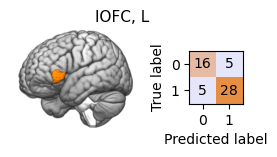

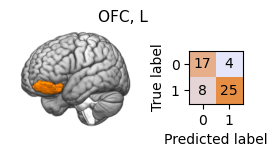

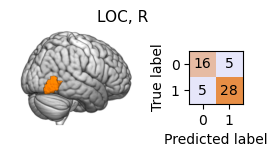

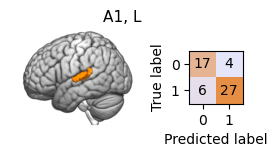

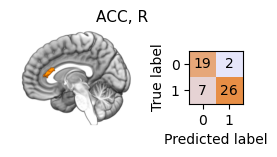

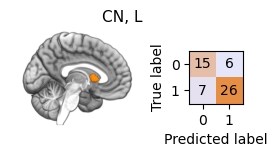

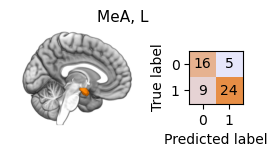

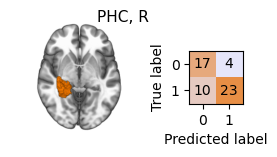

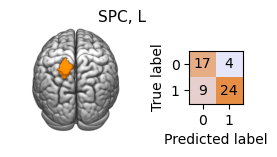

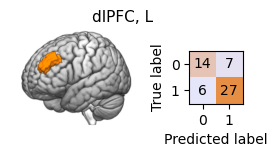

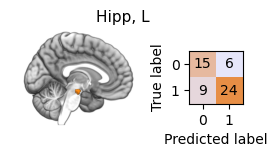

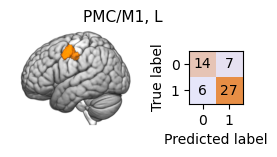

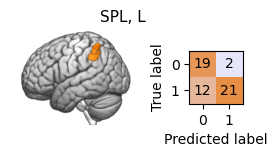

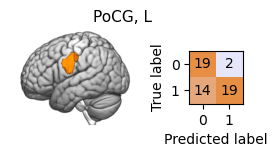

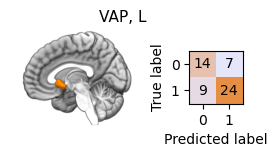

In [18]:
confusion_matrix_and_surface_plot_per_fold(visit2_gbm_bh_significant, base_path, model = "GBM", type_prediction = "visit2")